In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

Mounted at /content/drive
TF version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )
def bce_dice_loss(y_true, y_pred):
    bce = tf.reduce_mean(tf.keras.losses.binary_crossentropy(y_true, y_pred))
    dice = 1 - dice_coefficient(y_true, y_pred)
    return 0.5 * bce + 0.5 * dice

print("Loss functions defined ✓")

Loss functions defined ✓


In [ ]:
BASE = '/content/drive/MyDrive/LungTumour/'

# Load validation data
X_val = np.load(BASE + 'X_val.npy')
y_val = np.load(BASE + 'y_val.npy')

# Transpose to (N, 8, 128, 128, 1)
X_val = np.transpose(X_val, (0, 3, 1, 2, 4))
y_val = np.transpose(y_val, (0, 3, 1, 2, 4))

print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

# Load best model
model = load_model(
    BASE + 'M4_phase2_best.h5',
    custom_objects={
        'dice_coefficient': dice_coefficient,
        'bce_dice_loss': bce_dice_loss
    }
)

print("Model loaded ✓")

X_val shape: (526, 8, 128, 128, 1)
y_val shape: (526, 8, 128, 128, 1)


Model loaded ✓


In [ ]:
y_pred = model.predict(X_val, batch_size=2, verbose=1)
y_pred_bin = (y_pred > 0.5).astype(np.float32)

print("Predictions shape:", y_pred.shape)
print("Predictions done ✓")

263/263 ━━━━━━━━━━━━━━━━━━━━ 31s 96ms/step
Predictions shape: (526, 8, 128, 128, 1)
Predictions done ✓


In [ ]:
def compute_metrics(y_true, y_pred_bin):
    results = []

    for i in range(len(y_true)):
        gt   = y_true[i].flatten()
        pred = y_pred_bin[i].flatten()

        TP = np.sum(gt * pred)
        FP = np.sum((1 - gt) * pred)
        FN = np.sum(gt * (1 - pred))
        TN = np.sum((1 - gt) * (1 - pred))

        dice        = (2 * TP + 1e-6) / (2 * TP + FP + FN + 1e-6)
        iou         = (TP + 1e-6) / (TP + FP + FN + 1e-6)
        sensitivity = (TP + 1e-6) / (TP + FN + 1e-6)
        precision   = (TP + 1e-6) / (TP + FP + 1e-6)
        specificity = (TN + 1e-6) / (TN + FP + 1e-6)

        results.append({
            'dice': dice, 'iou': iou,
            'sensitivity': sensitivity,
            'precision': precision,
            'specificity': specificity
        })

    return results

results = compute_metrics(y_val, y_pred_bin)

metrics = ['dice', 'iou', 'sensitivity', 'precision', 'specificity']
print("\n===== Validation Metrics =====")
for m in metrics:
    vals = [r[m] for r in results]
    print(f"{m:>12s}:  mean={np.mean(vals):.4f}  std={np.std(vals):.4f}  min={np.min(vals):.4f}  max={np.max(vals):.4f}")


===== Validation Metrics =====
        dice:  mean=0.7073  std=0.2535  min=0.0000  max=0.9630
         iou:  mean=0.5932  std=0.2384  min=0.0000  max=0.9286
 sensitivity:  mean=0.7350  std=0.2777  min=0.0000  max=1.0000
   precision:  mean=0.7951  std=0.2027  min=0.0000  max=1.0000
 specificity:  mean=0.9992  std=0.0019  min=0.9816  max=1.0000


In [ ]:
# Separate good vs bad predictions
dice_scores = [r['dice'] for r in results]
dice_scores = np.array(dice_scores)

perfect    = np.sum(dice_scores > 0.85)
good       = np.sum((dice_scores > 0.70) & (dice_scores <= 0.85))
mediocre   = np.sum((dice_scores > 0.40) & (dice_scores <= 0.70))
failed     = np.sum((dice_scores > 0.01) & (dice_scores <= 0.40))
complete_miss = np.sum(dice_scores <= 0.01)

total = len(dice_scores)
print("===== Prediction Quality Distribution =====")
print(f"  Perfect   (Dice > 0.85) : {perfect:4d} / {total}  ({100*perfect/total:.1f}%)")
print(f"  Good      (0.70–0.85)   : {good:4d} / {total}  ({100*good/total:.1f}%)")
print(f"  Mediocre  (0.40–0.70)   : {mediocre:4d} / {total}  ({100*mediocre/total:.1f}%)")
print(f"  Failed    (0.01–0.40)   : {failed:4d} / {total}  ({100*failed/total:.1f}%)")
print(f"  Complete Miss (≤ 0.01)  : {complete_miss:4d} / {total}  ({100*complete_miss/total:.1f}%)")

print("\n===== Sensitivity Breakdown =====")
sens_scores = np.array([r['sensitivity'] for r in results])
print(f"  Sensitivity > 0.90 : {np.sum(sens_scores > 0.90):4d} / {total}  ({100*np.mean(sens_scores > 0.90):.1f}%)")
print(f"  Sensitivity < 0.50 : {np.sum(sens_scores < 0.50):4d} / {total}  ({100*np.mean(sens_scores < 0.50):.1f}%)")
print(f"  Sensitivity = 0.00 : {np.sum(sens_scores == 0.00):4d} / {total}  ({100*np.mean(sens_scores == 0.00):.1f}%)")

===== Prediction Quality Distribution =====
  Perfect   (Dice > 0.85) :  162 / 526  (30.8%)
  Good      (0.70–0.85)   :  227 / 526  (43.2%)
  Mediocre  (0.40–0.70)   :   74 / 526  (14.1%)
  Failed    (0.01–0.40)   :   24 / 526  (4.6%)
  Complete Miss (≤ 0.01)  :   39 / 526  (7.4%)

===== Sensitivity Breakdown =====
  Sensitivity > 0.90 :  163 / 526  (31.0%)
  Sensitivity < 0.50 :   77 / 526  (14.6%)
  Sensitivity = 0.00 :    0 / 526  (0.0%)


In [ ]:
dice_scores = np.array([r['dice'] for r in results])
miss_indices = np.where(dice_scores <= 0.01)[0]

print(f"Complete misses: {len(miss_indices)} samples")
print("\n===== Nodule Size in Missed Cases =====")

sizes = []
for idx in miss_indices:
    gt = y_val[idx]
    nodule_voxels = np.sum(gt)
    sizes.append(nodule_voxels)
    print(f"  Sample {idx:4d} | Nodule voxels: {int(nodule_voxels):6d} | Dice: {dice_scores[idx]:.4f}")

print(f"\nMean nodule size (misses) : {np.mean(sizes):.1f} voxels")
print(f"Mean nodule size (overall): {np.mean([np.sum(y_val[i]) for i in range(len(y_val))]):.1f} voxels")

Complete misses: 39 samples

===== Nodule Size in Missed Cases =====
  Sample    3 | Nodule voxels:     47 | Dice: 0.0000
  Sample    4 | Nodule voxels:     42 | Dice: 0.0000
  Sample   14 | Nodule voxels:     44 | Dice: 0.0000
  Sample   17 | Nodule voxels:     23 | Dice: 0.0000
  Sample   38 | Nodule voxels:   2588 | Dice: 0.0000
  Sample   85 | Nodule voxels:     43 | Dice: 0.0000
  Sample   88 | Nodule voxels:     47 | Dice: 0.0000
  Sample  114 | Nodule voxels:    212 | Dice: 0.0000
  Sample  121 | Nodule voxels:    324 | Dice: 0.0000
  Sample  143 | Nodule voxels:     22 | Dice: 0.0000
  Sample  146 | Nodule voxels:    119 | Dice: 0.0000
  Sample  153 | Nodule voxels:     41 | Dice: 0.0000
  Sample  163 | Nodule voxels:    165 | Dice: 0.0000
  Sample  180 | Nodule voxels:     46 | Dice: 0.0000
  Sample  191 | Nodule voxels:    214 | Dice: 0.0000
  Sample  200 | Nodule voxels:    104 | Dice: 0.0000
  Sample  214 | Nodule voxels:     44 | Dice: 0.0000
  Sample  230 | Nodule voxels:

Saved: /content/sample_38.png


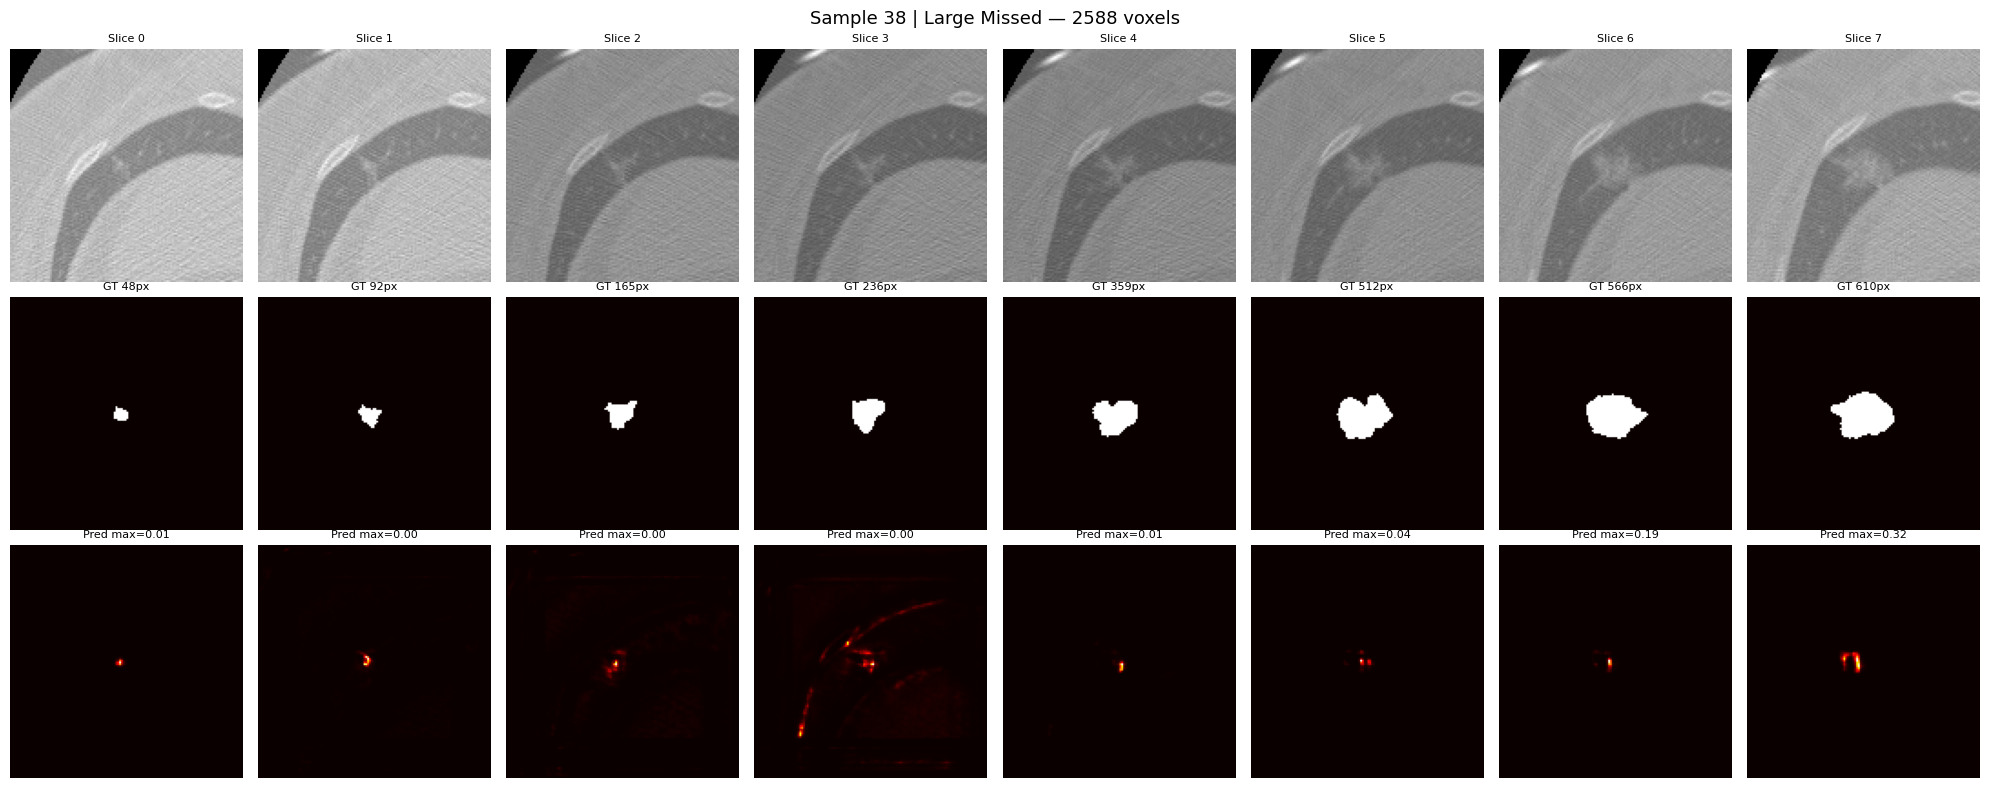

Saved: /content/sample_424.png


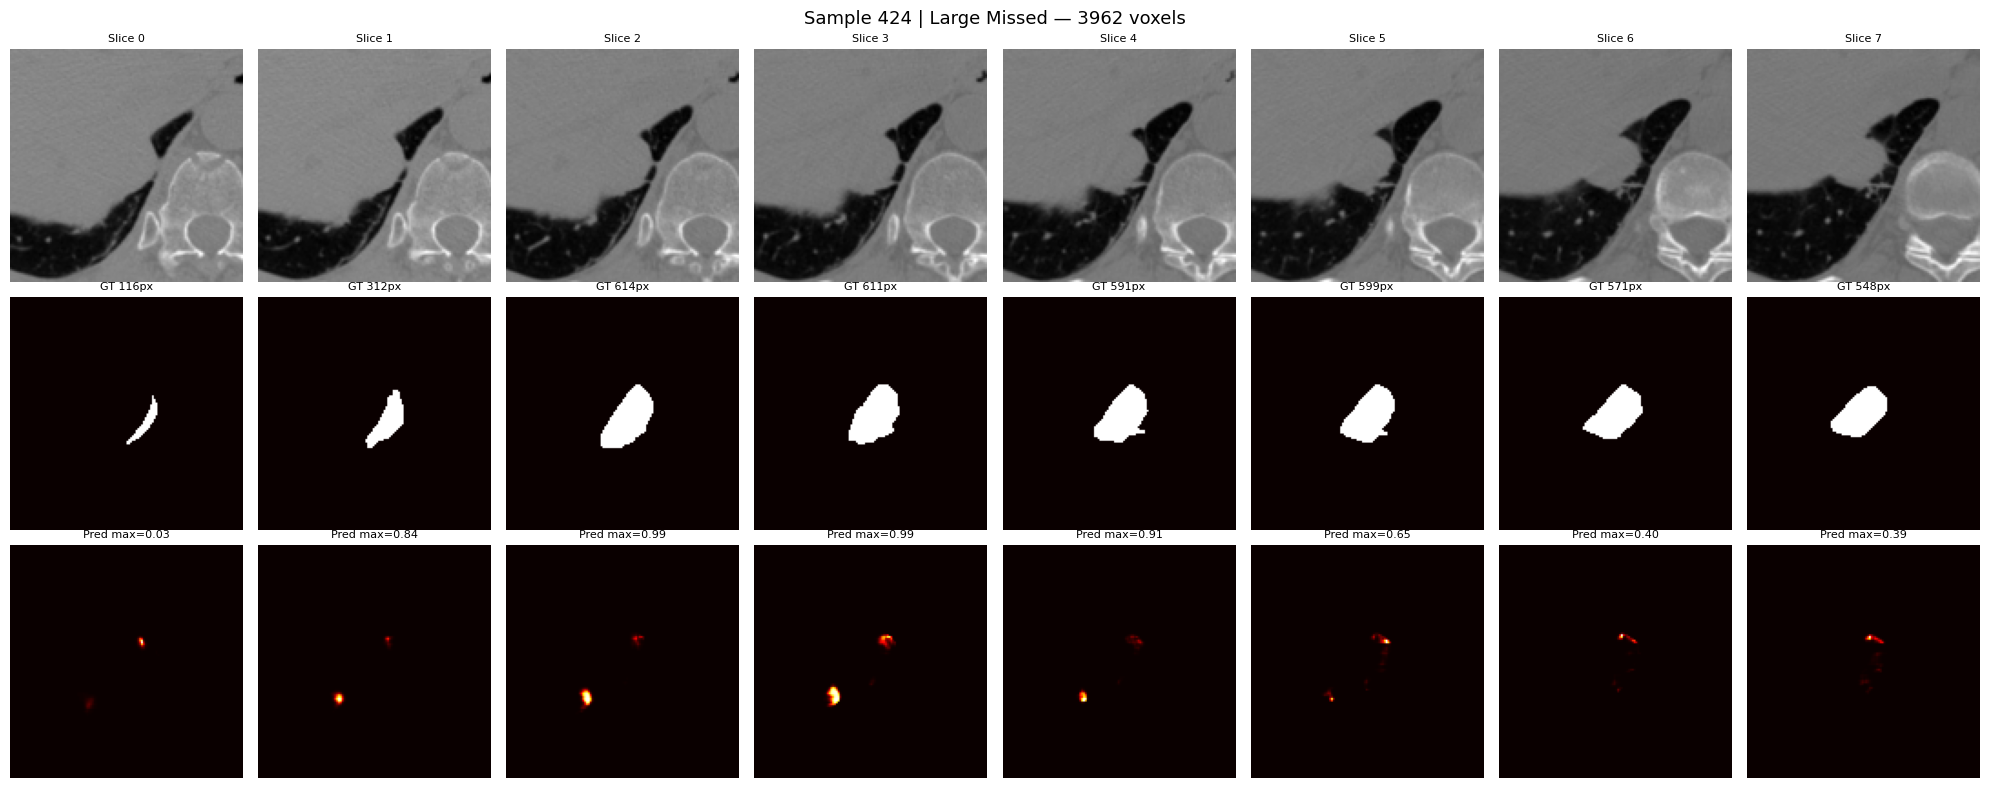

In [ ]:
def plot_miss(X, y_true, y_pred, y_pred_bin, idx, title=""):
    fig, axes = plt.subplots(3, 8, figsize=(20, 8))
    fig.suptitle(f"Sample {idx} | {title}", fontsize=13)

    for s in range(8):
        axes[0, s].imshow(X[idx, s, :, :, 0], cmap='gray')
        axes[0, s].set_title(f'Slice {s}', fontsize=8)
        axes[0, s].axis('off')

        axes[1, s].imshow(y_true[idx, s, :, :, 0], cmap='hot')
        axes[1, s].set_title(f'GT {int(np.sum(y_true[idx,s]))}px', fontsize=8)
        axes[1, s].axis('off')

        axes[2, s].imshow(y_pred[idx, s, :, :, 0], cmap='hot')
        axes[2, s].set_title(f'Pred max={y_pred[idx,s,:,:,0].max():.2f}', fontsize=8)
        axes[2, s].axis('off')

    axes[0, 0].set_ylabel('Input', fontsize=9)
    axes[1, 0].set_ylabel('Ground Truth', fontsize=9)
    axes[2, 0].set_ylabel('Raw Prediction', fontsize=9)
    # Add this at the end of Cell 8, inside the function before plt.show()
    plt.savefig(f'/content/sample_{idx}.png', dpi=100, bbox_inches='tight')
    print(f"Saved: /content/sample_{idx}.png")

    plt.tight_layout()
    plt.show()

# Visualize the two large missed nodules
plot_miss(X_val, y_val, y_pred, y_pred_bin, idx=38,
          title="Large Missed — 2588 voxels")

plot_miss(X_val, y_val, y_pred, y_pred_bin, idx=424,
          title="Large Missed — 3962 voxels")

In [ ]:
thresholds = np.arange(0.25, 0.55, 0.05)

print("Threshold | Mean Dice | Perfect | Complete Miss")
print("-" * 55)

for thresh in thresholds:
    pred_t = (y_pred > thresh).astype(np.float32)
    res = compute_metrics(y_val, pred_t)

    dice_vals = np.array([r['dice'] for r in res])
    mean_dice    = np.mean(dice_vals)
    perfect      = np.sum(dice_vals > 0.85)
    complete_miss = np.sum(dice_vals <= 0.01)

    marker = " ← current" if abs(thresh - 0.5) < 0.01 else ""
    print(f"  {thresh:.2f}    |  {mean_dice:.4f}   |  {perfect:4d}   |  {complete_miss:4d}{marker}")

Threshold | Mean Dice | Perfect | Complete Miss
-------------------------------------------------------
  0.25    |  0.7105   |   160   |    37
  0.30    |  0.7098   |   155   |    37
  0.35    |  0.7093   |   158   |    39
  0.40    |  0.7083   |   158   |    39
  0.45    |  0.7077   |   159   |    39
  0.50    |  0.7073   |   162   |    39 ← current
  0.55    |  0.7068   |   163   |    39


In [ ]:
!pip install gradio huggingface_hub -q
print("Done ✓")

Done ✓


In [ ]:

BASE = '/content/drive/MyDrive/LungTumour/'

# Load old .h5 model
model = load_model(
    BASE + 'M4_phase2_best.h5',
    custom_objects={
        'dice_coefficient': dice_coefficient,
        'bce_dice_loss': bce_dice_loss
    }
)

# Save in modern .keras format
model.save('/content/lung_tumor_model.keras')
print("Model converted and saved ✓")
print("File size:", round(os.path.getsize('/content/lung_tumor_model.keras') / 1e6, 1), "MB")

Model converted and saved ✓
File size: 5.8 MB


In [ ]:
app_code = '''
import gradio as gr
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib
matplotlib.use("Agg")
from PIL import Image
import io

# ── Custom loss functions ──────────────────────────────────────
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

def bce_dice_loss(y_true, y_pred):
    bce = tf.reduce_mean(tf.keras.losses.binary_crossentropy(y_true, y_pred))
    dice = 1 - dice_coefficient(y_true, y_pred)
    return 0.5 * bce + 0.5 * dice

# ── Load model ─────────────────────────────────────────────────
model = tf.keras.models.load_model(
    "lung_tumor_model.keras",
    custom_objects={
        "dice_coefficient": dice_coefficient,
        "bce_dice_loss": bce_dice_loss
    }
)
print("Model loaded ✓")

# ── Helper: get bounding box ───────────────────────────────────
def get_bbox(mask):
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)
    if not rows.any():
        return None
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    return rmin, cmin, rmax, cmax

# ── Helper: get location label ─────────────────────────────────
def get_location(bbox, img_size=128):
    if bbox is None:
        return "N/A"
    rmin, cmin, rmax, cmax = bbox
    cx = (cmin + cmax) / 2
    cy = (rmin + rmax) / 2
    v = "Upper" if cy < img_size // 2 else "Lower"
    h = "Left"  if cx < img_size // 2 else "Right"
    return f"{v}-{h} region"

# ── Predict function ───────────────────────────────────────────
def predict(npy_file):
    try:
        volume = np.load(npy_file.name)

        if volume.ndim == 3:
            volume = volume[..., np.newaxis]
        if volume.ndim == 4:
            volume = volume[np.newaxis]
        if volume.max() > 1.0:
            volume = volume / 255.0

        if volume.shape[1:] != (8, 128, 128, 1):
            return None, f"❌ Wrong shape: {volume.shape}. Expected (1,8,128,128,1)"

        pred       = model.predict(volume, verbose=0)
        pred_masks = pred[0, :, :, :, 0]           # (8, 128, 128)
        pred_bin   = (pred_masks > 0.5).astype(np.float32)
        input_vol  = volume[0, :, :, :, 0]         # (8, 128, 128)

        # ── Detection decision ─────────────────────────────────
        total_px      = int(np.sum(pred_bin))
        active_slices = int(np.sum(pred_bin.sum(axis=(1, 2)) > 0))
        max_conf      = float(pred_masks.max())
        detected      = total_px > 50 and max_conf > 0.5

        # Best slice = most nodule pixels
        best_slice = int(np.argmax(pred_bin.sum(axis=(1, 2))))
        bbox       = get_bbox(pred_bin[best_slice])
        location   = get_location(bbox)

        # Risk level
        if total_px > 800:
            risk = "High"
            risk_color = "#ff4444"
        elif total_px > 300:
            risk = "Medium"
            risk_color = "#ffaa00"
        else:
            risk = "Low"
            risk_color = "#44ff44"

        # ── Plot ───────────────────────────────────────────────
        fig, axes = plt.subplots(3, 8, figsize=(22, 9))
        fig.patch.set_facecolor("#0f0f0f")

        status_text = "⚠ TUMOR DETECTED" if detected else "✓ NO TUMOR DETECTED"
        status_color = "#ff4444" if detected else "#44ff88"
        fig.suptitle(status_text, color=status_color, fontsize=16,
                     fontweight="bold", y=1.02)

        for s in range(8):
            is_best = (s == best_slice)
            border_color = "#ff4444" if is_best else "#333333"

            # Row 0 — Input
            axes[0, s].imshow(input_vol[s], cmap="gray")
            axes[0, s].set_title(f"Slice {s}" + (" ★" if is_best else ""),
                                 color="#ffdd00" if is_best else "white",
                                 fontsize=8, fontweight="bold" if is_best else "normal")
            axes[0, s].axis("off")
            for spine in axes[0, s].spines.values():
                spine.set_edgecolor(border_color)
                spine.set_linewidth(2)

            # Row 1 — Heatmap
            axes[1, s].imshow(pred_masks[s], cmap="hot", vmin=0, vmax=1)
            axes[1, s].set_title(f"conf={pred_masks[s].max():.2f}",
                                 color="white", fontsize=7)
            axes[1, s].axis("off")

            # Row 2 — Overlay + bounding box on best slice
            axes[2, s].imshow(input_vol[s], cmap="gray")
            axes[2, s].imshow(pred_bin[s], cmap="Reds", alpha=0.5)

            if is_best and bbox is not None:
                rmin, cmin, rmax, cmax = bbox
                rect = mpatches.Rectangle(
                    (cmin, rmin), cmax - cmin, rmax - rmin,
                    linewidth=2, edgecolor="#ff4444",
                    facecolor="none", linestyle="--"
                )
                axes[2, s].add_patch(rect)
                axes[2, s].text(
                    cmin, rmin - 4, "TUMOR",
                    color="#ff4444", fontsize=7, fontweight="bold"
                )

            axes[2, s].set_title(f"{int(pred_bin[s].sum())}px",
                                 color="white", fontsize=7)
            axes[2, s].axis("off")

        for row, label in enumerate(["Input CT", "Confidence", "Segmentation"]):
            axes[row, 0].set_ylabel(label, color="white", fontsize=9)

        plt.tight_layout()
        buf = io.BytesIO()
        plt.savefig(buf, format="png", dpi=100,
                    bbox_inches="tight", facecolor="#0f0f0f")
        buf.seek(0)
        result_img = Image.open(buf).copy()
        plt.close()

        # ── Detection report ───────────────────────────────────
        if detected:
            info = (
                f"⚠️  TUMOR DETECTED\\n"
                f"{'─'*35}\\n"
                f"Location      : {location}\\n"
                f"Best slice    : Slice {best_slice} (★ highlighted)\\n"
                f"Active slices : {active_slices} / 8\\n"
                f"Nodule size   : {total_px} pixels\\n"
                f"Confidence    : {max_conf*100:.1f}%\\n"
                f"Risk level    : {risk}\\n"
                f"{'─'*35}\\n"
                f"⚠ This is a research demo only.\\n"
                f"Consult a radiologist for diagnosis."
            )
        else:
            info = (
                f"✅  NO TUMOR DETECTED\\n"
                f"{'─'*35}\\n"
                f"Max confidence : {max_conf*100:.1f}%\\n"
                f"Nodule pixels  : {total_px}\\n"
                f"{'─'*35}\\n"
                f"⚠ This is a research demo only.\\n"
                f"Consult a radiologist for diagnosis."
            )

        return result_img, info

    except Exception as e:
        return None, f"❌ Error: {str(e)}"

# ── Gradio UI ──────────────────────────────────────────────────
with gr.Blocks(theme=gr.themes.Monochrome(),
               title="Lung Tumor Segmentation") as demo:

    gr.Markdown("""
    # 🫁 Lung Tumor Segmentation — AI Demo
    **Model:** 3D U-Net | **Dataset:** LIDC-IDRI | **Val Dice:** 0.7484
    Upload a `.npy` CT volume → Model segments and detects tumor region
    """)

    with gr.Row():
        with gr.Column(scale=1):
            inp = gr.File(label="Upload .npy CT Volume", file_types=[".npy"])
            btn = gr.Button("🔍 Run Detection", variant="primary")
            gr.Markdown("""
            **How to prepare input:**
```python
            import numpy as np
            sample = X_val[0]  # (8,128,128,1)
            np.save("sample.npy", sample)
```
            Upload `sample.npy` here.
            """)

        with gr.Column(scale=2):
            out_img  = gr.Image(label="Detection Result")
            out_text = gr.Textbox(label="🏥 Detection Report", lines=10)

    btn.click(fn=predict, inputs=inp, outputs=[out_img, out_text])

    gr.Markdown("""
    ---
    > ★ = Best slice (most tumor pixels) | Red box = Tumor location
    > Row 1: Input CT | Row 2: Confidence heatmap | Row 3: Segmentation overlay
    > Built by **TanishDevX** | LIDC-IDRI | 3D U-Net ~1.4M params
    """)

demo.launch()
'''

with open('/content/app.py', 'w') as f:
    f.write(app_code)

print("app.py rewritten ✓")

app.py rewritten ✓


In [ ]:
requirements = '''gradio
tensorflow
numpy
matplotlib
Pillow
'''

with open('/content/requirements.txt', 'w') as f:
    f.write(requirements)

print("requirements.txt created ✓")

requirements.txt created ✓


In [ ]:
from huggingface_hub import HfApi, login

# Step 1 — Login with token directly (paste your token inside quotes)
login(token="hf_YOUR_TOKEN_HERE")  # ← replace with your actual token

# Step 2 — Verify login worked
api = HfApi()
user = api.whoami()
print(f"Logged in as: {user['name']} ✓")

Logged in as: TanishDevX ✓


In [ ]:
USERNAME  = "TanishDevX"
REPO_NAME = "lung-tumor-segmentation"
REPO_ID   = f"{USERNAME}/{REPO_NAME}"

# Create Space
api.create_repo(
    repo_id=REPO_ID,
    repo_type="space",
    space_sdk="gradio",
    exist_ok=True
)
print(f"Space created ✓")

# Upload files
files_to_upload = {
    '/content/app.py'                 : 'app.py',
    '/content/requirements.txt'       : 'requirements.txt',
    '/content/lung_tumor_model.keras' : 'lung_tumor_model.keras',
}

for local_path, repo_path in files_to_upload.items():
    print(f"Uploading {repo_path}...")
    api.upload_file(
        path_or_fileobj=local_path,
        path_in_repo=repo_path,
        repo_id=REPO_ID,
        repo_type="space"
    )
    print(f"  ✓ {repo_path} done")

print(f"\n✅ All uploaded!")
print(f"🚀 https://huggingface.co/spaces/{REPO_ID}")
print("⏳ Wait 2-3 mins for build, then open the link")

Space created ✓
Uploading app.py...
  ✓ app.py done
Uploading requirements.txt...
  ✓ requirements.txt done
Uploading lung_tumor_model.keras...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...nt/lung_tumor_model.keras:  19%|#9        | 1.11MB / 5.80MB            

  ✓ lung_tumor_model.keras done

✅ All uploaded!
🚀 https://huggingface.co/spaces/TanishDevX/lung-tumor-segmentation
⏳ Wait 2-3 mins for build, then open the link


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Save a few test images from val set
for i in [0, 5, 10]:
    img = X_val[i, 4, :, :, 0]  # middle slice
    plt.imsave(f'/content/test_slice_{i}.png', img, cmap='gray')
    print(f"Saved test_slice_{i}.png")

print("Download these from Colab Files panel and upload to your app!")

Saved test_slice_0.png
Saved test_slice_5.png
Saved test_slice_10.png
Download these from Colab Files panel and upload to your app!


In [ ]:
# Save one sample from val set as .npy for testing
sample = X_val[0]   # shape (8, 128, 128, 1)
np.save('/content/sample.npy', sample)
print("Shape:", sample.shape)
print("Saved: sample.npy ✓")
print("Download from Colab Files panel → upload to your app")

Shape: (8, 128, 128, 1)
Saved: sample.npy ✓
Download from Colab Files panel → upload to your app


In [ ]:
# Save multiple test samples
for idx in [0, 5, 38, 100]:
    sample = X_val[idx]
    np.save(f'/content/sample_{idx}.npy', sample)
    print(f"Saved sample_{idx}.npy")

Saved sample_0.npy
Saved sample_5.npy
Saved sample_38.npy
Saved sample_100.npy


In [ ]:
import numpy as np

dice_scores = np.array([r['dice'] for r in results])

# Get top 10 best predicted samples
top_indices = np.argsort(dice_scores)[::-1][:10]

print("Top 10 samples for demo:")
for idx in top_indices:
    print(f"  Sample {idx} → Dice: {dice_scores[idx]:.4f}")
    np.save(f'/content/demo_sample_{idx}.npy', X_val[idx])

print("\nDownload these for your demo!")

Top 10 samples for demo:
  Sample 116 → Dice: 0.9630
  Sample 490 → Dice: 0.9593
  Sample 426 → Dice: 0.9473
  Sample 416 → Dice: 0.9410
  Sample 174 → Dice: 0.9399
  Sample 62 → Dice: 0.9369
  Sample 521 → Dice: 0.9365
  Sample 427 → Dice: 0.9354
  Sample 149 → Dice: 0.9352
  Sample 372 → Dice: 0.9351

Download these for your demo!
